### Business Hypothesis (Statistical Test)
### 🎯 Hypothesis

### H0 (Null): High discount does NOT reduce average profit
### H1 (Alternative): High discount significantly reduces average profit

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [6]:
df["Discount_Group"] = np.where(df["Discount"] > 0.2, "High", "Low")

high_profit = df[df["Discount_Group"] == "High"]["Profit"]
low_profit = df[df["Discount_Group"] == "Low"]["Profit"]

In [7]:
t_stat, p_value = stats.ttest_ind(high_profit, low_profit)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -22.134190085874568
P-Value: 5.092886028896182e-106


In [8]:
X = df[["Sales", "Quantity", "Discount", "Category", "Region"]]
y = df["Profit"]

In [9]:
categorical_cols = ["Category", "Region"]
numerical_cols = ["Sales", "Quantity", "Discount"]

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

In [11]:
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42))
])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: -0.13400629681860599
MAE: 38.21552398330875


In [15]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

Cross Validation R2 Scores: [0.44222616 0.07327061 0.76688911 0.75793099 0.81507656]
Average CV R2: 0.5710786858604495


In [16]:
q_low = df["Profit"].quantile(0.01)
q_high = df["Profit"].quantile(0.99)

df_filtered = df[(df["Profit"] > q_low) & (df["Profit"] < q_high)]

X_f = df_filtered[["Sales", "Quantity", "Discount", "Category", "Region"]]
y_f = df_filtered["Profit"]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f, y_f, test_size=0.2, random_state=42
)

model.fit(X_train_f, y_train_f)
y_pred_f = model.predict(X_test_f)

print("Improved R2:", r2_score(y_test_f, y_pred_f))
print("Improved MAE:", mean_absolute_error(y_test_f, y_pred_f))

Improved R2: 0.7382052067825515
Improved MAE: 17.301706442841486


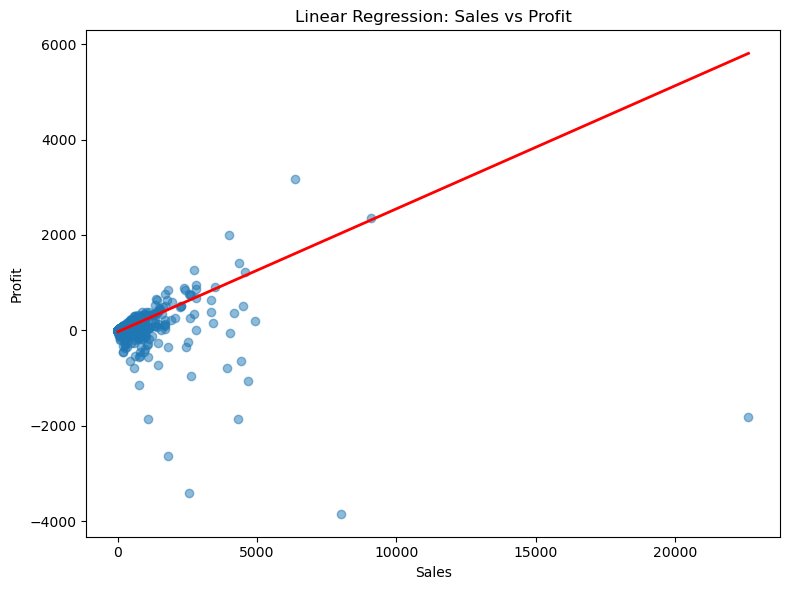

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Select feature and target
X = df[["Sales"]].values
y = df["Profit"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Sort for proper line plotting
sorted_idx = X_test[:, 0].argsort()
X_test_sorted = X_test[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, alpha=0.5)
plt.plot(X_test_sorted, y_pred_sorted, color="red", linewidth=2)

plt.title("Linear Regression: Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()